# Hypotheses
1. **Limited visibility**: The company has limited data on the shipping and delivery stages, making it difficult to accurately assess the full delivery process. 
2. **Warehouse processing time**: Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average. 
3. **Express orders**: Express orders are processed and shipped significantly faster than standard orders.  
4. **Weekend orders** take longer to process than weekday orders. 
5. **Orders ready on Friday** experience longer waiting times because trucks leave only on Monday, Wednesday, and Friday. - delivery time by day of the order
6. **Some orders** miss the next available truck. 
7. **Transportation** takes approximately three days after shipment. 
8. **Most variation in delivery time** comes from warehouse processing or waiting for a truck. 
9. **Daily pickups** would reduce total delivery time. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

***First Dataset***

In [2]:
orders_raw = pd.read_excel('data/Muesli Project raw data.xlsx', sheet_name='Orders', header = 1)
orders_raw.head(3) 

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500


In [3]:
orders_raw.info() #gives us the shape of the dataset, the dtypes, null counts and column names

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Index           9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Origin Channel  9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   str           
 12  Category        9994 non-null   str           
 13  Sub-Category    9994 non-null   str           
 14  Product ID      9994 non-null   str           
 15  Sales          

**Cleaning the first Data Set**

In [4]:
orders_raw.isnull().sum() #eleven postal codes are missing

Index              0
Order ID           0
Order Date         0
Ship Mode          0
Customer ID        0
Customer Name      0
Origin Channel     0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Category           0
Sub-Category       0
Product ID         0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [ ]:
# cleaning the column names

orders_raw.columns = (orders_raw.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_'))

In [6]:
#To indentify the missing records
orders_raw[orders_raw['postal_code'].isna()]
#the postal code for state vermont in the city burlington is missing for the region east

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
173,2235,CA-2020-104066,2020-12-05,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10001013,205.03,7,0.0,67.6599
710,9147,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10002926,99.98,2,0.0,42.9914
1732,9389,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Mega Protein,OFF-AP-10000828,542.94,3,0.0,152.0232
3408,9387,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10000157,79.92,4,0.0,37.5624
3409,9388,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10001970,12.28,1,0.0,5.7716
4279,8799,US-2019-150140,2019-04-06,Standard Class,VM-21685,Valerie Mitchum,Facebook,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Only Oats,TEC-PH-10002555,1294.75,5,0.0,336.6350
4694,9390,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Power Clean Fibre Boost,OFF-EN-10001509,2.04,1,0.0,0.9588
5490,9149,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Steel Cut,OFF-ST-10001526,1564.29,13,0.0,406.7154
7802,9148,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Super Mega Protein,OFF-AR-10003477,8.04,6,0.0,2.7336
8415,9742,CA-2018-117086,2018-11-08,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Toasted Muesli,With Fruit,FUR-BO-10004834,4404.90,5,0.0,1013.1270


In [7]:
#To check the postal codes that do exist for Burlington, Vermont in the dataset. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
orders_raw[
    (orders_raw['city'] == 'Burlington') &
    (orders_raw['state'] == 'Vermont')]['postal_code'].value_counts(dropna=False)

postal_code
NaN    11
Name: count, dtype: int64

In [8]:
#filling the postal code with 05401 and changing into a string
orders_raw['postal_code'] = orders_raw['postal_code'].astype('string')

orders_raw.loc[
    orders_raw['postal_code'].isna(),
    'postal_code'
] = '05401'

In [9]:
#checking if it worked and it did :)
orders_raw.isnull().sum() 

index             0
order_id          0
order_date        0
ship_mode         0
customer_id       0
customer_name     0
origin_channel    0
country_region    0
city              0
state             0
postal_code       0
region            0
category          0
sub_category      0
product_id        0
sales             0
quantity          0
discount          0
profit            0
dtype: int64

In [10]:
#checking for duplicates and there are no duplicates
orders_raw.duplicated().sum()

np.int64(0)

In [11]:
#To fix the data types

orders_raw['order_date'] = pd.to_datetime(orders_raw['order_date'])

orders_raw['sales'] = pd.to_numeric(orders_raw['sales'])
orders_raw['quantity'] = pd.to_numeric(orders_raw['quantity'])
orders_raw['discount'] = pd.to_numeric(orders_raw['discount'])
orders_raw['profit'] = pd.to_numeric(orders_raw['profit'])

orders_raw.dtypes

index                      int64
order_id                     str
order_date        datetime64[us]
ship_mode                    str
customer_id                  str
customer_name                str
origin_channel               str
country_region               str
city                         str
state                        str
postal_code               string
region                       str
category                     str
sub_category                 str
product_id                   str
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
dtype: object

**Analysing the first Dataset**

In [12]:
#checking the values for the columns:ship mode, region, category
print("ship_mode:")
display(orders_raw['ship_mode'].value_counts())

print("origin_channel:")
display(orders_raw['origin_channel'].value_counts())

print("region:")
display(orders_raw['region'].value_counts())

print("category:")
display(orders_raw['category'].value_counts())



ship_mode:


ship_mode
Standard Class    5968
First Class       2081
Second Class      1945
Name: count, dtype: int64

origin_channel:


origin_channel
Email       5191
Sales       3020
Facebook    1783
Name: count, dtype: int64

region:


region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

category:


category
Power Muesli               6026
Toasted Muesli             2121
Special Projects Muesil    1847
Name: count, dtype: int64

In [13]:

orders_raw[['sales', 'quantity', 'discount', 'profit']].describe()

,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [14]:
print("Unique Order IDs:")
display(orders_raw['order_id'].nunique())

print("Unique Customer IDs:")
display(orders_raw['customer_id'].nunique())

print("Unique Product IDs:")
display(orders_raw['product_id'].nunique())

Unique Order IDs:


5009

Unique Customer IDs:


793

Unique Product IDs:


1862

In [15]:
#checking numerical range and outlier
orders_raw[['sales', 'quantity', 'discount', 'profit']].describe()

,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [16]:
Q1 = orders_raw['sales'].quantile(0.25)
Q3 = orders_raw['sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Sales lower bound:", lower)
print("Sales upper bound:", upper)

Sales lower bound: -271.71000000000004
Sales upper bound: 498.93


In [17]:
# Check for suspicious values

print("Sales < 0:")
display(orders_raw[orders_raw['sales'] < 0]) #no result

print("Quantity <= 0:")
display(orders_raw[orders_raw['quantity'] <= 0]) #no result

print("Discount < 0:")
display(orders_raw[orders_raw['discount'] < 0])#no result

print("Discount > 1:")
display(orders_raw[orders_raw['discount'] > 1]) #no result

print("Profit < 0:")
display(orders_raw[orders_raw['profit'] < 0])

Sales < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Quantity <= 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Discount < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Discount > 1:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Profit < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
6,101,CA-2019-158568,2019-08-29,Standard Class,RB-19465,Rick Bensley,Facebook,United States,Chicago,Illinois,60610.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10001767,95.976,3,0.2,-10.7973
7,104,US-2018-156867,2018-11-13,Standard Class,LC-16870,Lena Cacioppo,Email,United States,Aurora,Colorado,80013.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10001552,238.896,6,0.2,-26.8758
16,236,US-2020-100930,2020-04-07,Standard Class,CS-12400,Christopher Schild,Facebook,United States,Tampa,Florida,33614.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10003832,617.976,3,0.2,-7.7247
27,376,US-2017-119137,2017-07-23,Standard Class,AG-10900,Arthur Gainer,Email,United States,Tucson,Arizona,85705.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10002076,479.040,10,0.2,-29.9400
29,386,US-2018-168935,2018-11-27,Standard Class,DO-13435,Denny Ordway,Email,United States,Pembroke Pines,Florida,33024.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10002335,83.976,3,0.2,-1.0497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,9791,CA-2020-144491,2020-03-27,Standard Class,CJ-12010,Caroline Jumper,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10001714,211.246,2,0.3,-66.3916
9983,9793,CA-2017-127166,2017-05-21,Second Class,KH-16360,Katherine Hughes,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10003396,107.772,2,0.3,-29.2524
9985,9827,US-2017-164406,2017-08-15,Standard Class,BD-11605,Brian Dahlen,Email,United States,San Francisco,California,94122.0,West,Toasted Muesli,With Nuts,FUR-CH-10003833,195.136,4,0.2,-12.1960
9991,9913,CA-2018-132388,2018-10-10,First Class,KN-16390,Katherine Nockton,Sales,United States,Santa Barbara,California,93101.0,West,Toasted Muesli,With Nuts,FUR-CH-10001714,362.136,3,0.2,-54.3204


In [18]:
# Check whether identifiers behave as expected

print("Unique Order IDs:")
display(orders_raw['order_id'].nunique())

print("Unique Customer IDs:")
display(orders_raw['customer_id'].nunique())

print("Unique Product IDs:")
display(orders_raw['product_id'].nunique())

#The dataset contains 5,009 orders made by 793 customers, involving 1,862 different products.
#5,009 orders vs. 793 customers → customers place multiple orders on average.
#1,862 products vs. 5,009 orders → many orders likely contain products that also appear in other orders.
#One order can consist of multiple order lines/products, meaning the same order_id can appear multiple times.

Unique Order IDs:


5009

Unique Customer IDs:


793

Unique Product IDs:


1862

In [19]:
#to check repeated orders

orders_raw['order_id'].value_counts().head(10) #shows that same customers ordered several times

order_id
CA-2020-100111    14
CA-2020-157987    12
CA-2019-165330    11
US-2019-108504    11
CA-2018-131338    10
US-2018-126977    10
CA-2019-105732    10
CA-2020-117457     9
CA-2017-106439     9
CA-2020-140949     9
Name: count, dtype: int64

In [20]:
#To check whether the customer has multiple orders                      

orders_raw.groupby('customer_id')['order_id'].nunique().describe()
# 6.3 orders per customer; someone ordered 17 times

count    793.000000
mean       6.316520
std        2.550885
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: order_id, dtype: float64

***Second Dataset***

In [21]:
campaign_raw = pd.read_excel('data/Muesli Project raw data.xlsx', sheet_name='Campaign Data')
campaign_raw.head()

,Order ID,Arrival Scan Date,Customer Name
0,CA-2019-109666,2019-05-03,Kunst Miller
1,CA-2019-138933,2019-05-03,Jack Lebron
2,CA-2019-130001,2019-05-03,Heather Kirkland
3,CA-2019-113061,2019-05-06,Ed Ludwig
4,CA-2019-162138,2019-05-06,Grace Kelly


In [22]:
# Your code here — .info(), .describe()             
campaign_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    str           
 1   Arrival Scan Date  333 non-null    datetime64[us]
 2   Customer Name      333 non-null    str           
dtypes: datetime64[us](1), str(2)
memory usage: 7.9 KB


**Cleaning the Second Dataset**

In [23]:
#cleaning the column names

campaign_raw.columns = (campaign_raw.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_'))

In [24]:
campaign_raw.isnull().sum() #no missing values

order_id             0
arrival_scan_date    0
customer_name        0
dtype: int64

In [25]:
campaign_raw.duplicated().sum() #no duplicates either

np.int64(0)

**Analysing the Second Dataset**

In [26]:
campaign_raw.describe()

#the company said data over past few years, its only 1 year

,arrival_scan_date
count,333
mean,2019-10-14 19:36:12.972973
min,2019-05-03 00:00:00
25%,2019-09-09 00:00:00
50%,2019-10-21 00:00:00
75%,2019-12-16 00:00:00
max,2020-05-15 00:00:00


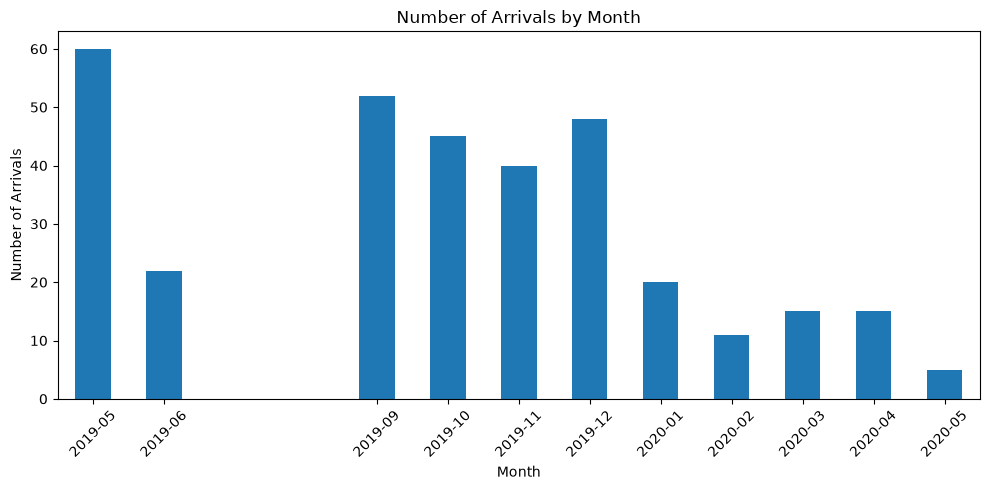

In [27]:
# Count the number of arrivals for each month
monthly_arrivals = (campaign_raw.groupby(campaign_raw['arrival_scan_date'].dt.to_period('M')) .size())

# Create a bar chart to visualize monthly arrivals
monthly_arrivals.plot(kind='bar',figsize=(10, 5))

plt.title('Number of Arrivals by Month')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#there is a pause from july to september 2019

***Third Dataset***

In [28]:
order_process_raw = pd.read_excel('data/Muesli Project raw data.xlsx', sheet_name='Order Process Data')
order_process_raw.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [29]:
#shows shape, null count, dtypes, column names
order_process_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   str           
 2   Order Date          5899 non-null   datetime64[us]
 3   On Truck Scan Date  5899 non-null   datetime64[us]
 4   Ship Mode           5899 non-null   str           
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 230.6 KB


**Cleaning the Third Dataset**

In [30]:
order_process_raw.isnull().sum()
#no missing data

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [31]:
order_process_raw.duplicated().sum()
#no duplicates

np.int64(0)

In [32]:
# cleaning the column names
order_process_raw.columns = ( order_process_raw.columns.str.strip().str.lower() .str.replace(' ', '_').str.replace('/', '_') .str.replace('-', '_'))

In [33]:
# Convert the order date and truck scan date columns to datetime format.
# This allows us to work with the dates correctly, for example
# when calculating delivery times or analyzing orders over time.

order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])
order_process_raw['on_truck_scan_date'] = pd.to_datetime(order_process_raw['on_truck_scan_date'])

**Analysing the Third Dataset**

In [34]:
#To check the date range to make sure whether the date make sense
print("Order date:")
print(order_process_raw['order_date'].min())
print(order_process_raw['order_date'].max())

print("\nTruck scan date:")
print(order_process_raw['on_truck_scan_date'].min())
print(order_process_raw['on_truck_scan_date'].max())


Order date:
2019-01-02 00:00:00
2020-12-30 00:00:00

Truck scan date:
2019-01-07 00:00:00
2021-01-06 00:00:00


In [35]:
# To check for invalid dates to make sure no order was scanned before it was ordered.
invalid_dates = order_process_raw[
    order_process_raw['on_truck_scan_date'] < order_process_raw['order_date']  ]

len(invalid_dates)

0

In [36]:
#To calculate warehouse processing time
order_process_raw['processing_days'] = ( order_process_raw['on_truck_scan_date'] -order_process_raw['order_date']).dt.days
order_process_raw[['order_date', 'on_truck_scan_date', 'processing_days']].head()

,order_date,on_truck_scan_date,processing_days
0,2019-01-03,2019-01-07,4
1,2019-01-02,2019-01-09,7
2,2019-01-02,2019-01-09,7
3,2019-01-03,2019-01-09,6
4,2019-01-03,2019-01-09,6


In [37]:
order_process_raw['processing_days'].describe() 

count    5899.000000
mean        6.120529
std         2.509031
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        12.000000
Name: processing_days, dtype: float64

In [38]:
order_process_raw['processing_days'].describe().to_frame()

,processing_days
count,5899.000000
mean,6.120529
std,2.509031
min,0.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,12.000000


## Hypothesis 2
 **Warehouse processing time**: Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average.
- Average processing time = 6.12 days.
- Median processing time = 7 days. based on the current data, the warehouse is not normally processing orders within 2 days.

In [39]:
#To check 2 days target
order_process_raw['within_2_days'] = (order_process_raw['processing_days'] <= 2)
order_process_raw['within_2_days'].value_counts()

within_2_days
False    5277
True      622
Name: count, dtype: int64

In [40]:
order_process_raw['within_2_days'].mean() * 100
# This means 10.54% of your orders were processed within 2 days.

np.float64(10.54416002712324)

In [41]:
# How many orders miss the target?
orders_over_2_days = (order_process_raw['processing_days'] > 2).sum()

orders_over_2_days

np.int64(5277)

In [42]:
orders_over_2_days / len(order_process_raw) * 100

np.float64(89.45583997287676)

In [43]:
# To analyze processing time by Ship Mode, because different shipping methods may have different warehouse processing patterns.
order_process_raw.groupby('ship_mode')['processing_days'].describe()

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
Express,1303.0,2.568688,1.638534,0.0,1.0,3.0,4.0,6.0
Standard Processing,4596.0,7.127502,1.651674,2.0,6.0,7.0,8.0,12.0


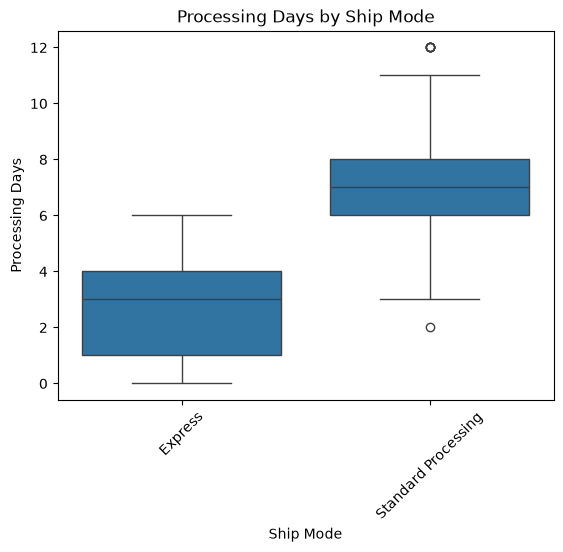

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize processing days by shipping mode
sns.boxplot(
    data=order_process_raw,
    x='ship_mode',
    y='processing_days'
)

plt.title('Processing Days by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Processing Days')
plt.xticks(rotation=45)
plt.show()

## Hypothesis 3
**Express orders**: Express orders are processed and shipped significantly faster than standard orders. 

- Express: about 47.66% of orders met the 2-day target. Standard Processing: only about 0.02% met the 2-day target.
- there are 152 outliers with 0 processing days and these were the express mode as well


In [45]:
order_process_raw.groupby('ship_mode')['within_2_days'].mean() * 100

# Express: about 47.66% of orders met the 2-day target. Standard Processing: only about 0.02% met the 2-day target.

ship_mode
Express                47.659248
Standard Processing     0.021758
Name: within_2_days, dtype: float64

In [46]:
#To identify extreme delays
Q1 = order_process_raw['processing_days'].quantile(0.25)
Q3 = order_process_raw['processing_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5.0
Q3: 8.0
IQR: 3.0
Lower bound: 0.5
Upper bound: 12.5


In [47]:
outliers = order_process_raw[(order_process_raw['processing_days'] < lower_bound) |(order_process_raw['processing_days'] > upper_bound)]
outliers
#152 rows, so there are 152 outliers

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days
179,1705,CA-2019-106306,2019-03-08,2019-03-08,Express,0,True
181,9698,CA-2019-122511,2019-03-11,2019-03-11,Express,0,True
282,7695,CA-2019-118899,2019-03-22,2019-03-22,Express,0,True
291,3371,CA-2019-134887,2019-03-25,2019-03-25,Express,0,True
317,8572,CA-2019-162222,2019-04-03,2019-04-03,Express,0,True
...,...,...,...,...,...,...,...
5594,6716,CA-2020-107629,2020-12-14,2020-12-14,Express,0,True
5687,4104,CA-2020-137456,2020-12-21,2020-12-21,Express,0,True
5698,883,US-2020-123463,2020-12-23,2020-12-23,Express,0,True
5746,4620,CA-2020-145219,2020-12-24,2020-12-24,Express,0,True


In [48]:
# to inspect the outlier

outliers[['order_id', 'order_date',  'on_truck_scan_date', 'ship_mode', 'processing_days']].sort_values('processing_days', ascending=False)

,order_id,order_date,on_truck_scan_date,ship_mode,processing_days
179,CA-2019-106306,2019-03-08,2019-03-08,Express,0
4021,US-2020-118941,2020-08-12,2020-08-12,Express,0
3748,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3749,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3768,US-2020-152492,2020-07-06,2020-07-06,Express,0
...,...,...,...,...,...
2275,US-2019-148803,2019-12-11,2019-12-11,Express,0
2276,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2277,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2278,CA-2019-162187,2019-12-11,2019-12-11,Express,0


In [49]:
#To analyze the distribution
order_process_raw['processing_days'].value_counts().sort_index()


processing_days
0      152
1      248
2      222
3      373
4      435
5      602
6      765
7     1165
8     1022
9      565
10     318
11      26
12       6
Name: count, dtype: int64

In [50]:
#To show inn percentage
order_process_raw['processing_days'].value_counts( normalize=True).sort_index() * 100

processing_days
0      2.576708
1      4.204102
2      3.763350
3      6.323106
4      7.374131
5     10.205120
6     12.968300
7     19.749110
8     17.324970
9      9.577895
10     5.390744
11     0.440753
12     0.101712
Name: proportion, dtype: float64

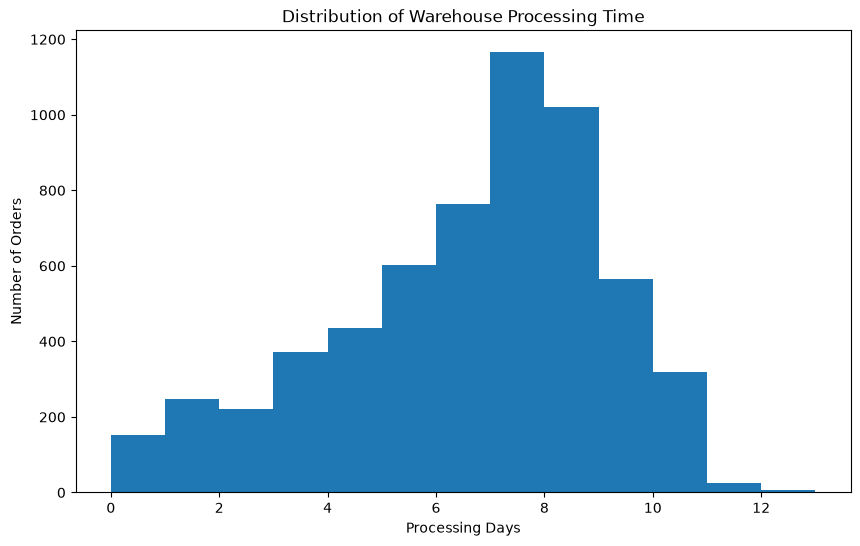

In [51]:
# To create visualization

plt.figure(figsize=(10, 6))
plt.hist(order_process_raw['processing_days'], bins=range(
    order_process_raw['processing_days'].min(),
    order_process_raw['processing_days'].max() + 2
))
plt.xlabel('Processing Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Warehouse Processing Time')
plt.show()

***Fourth Dataset***

In [52]:
intern_data_study = pd.read_excel('data/Muesli Project raw data.xlsx', sheet_name='InternData Study')
intern_data_study.head()

,Order ID,Ready to Ship Date,Pickup Date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


In [53]:
#check the shape, columns, dtypes and nullcounts
intern_data_study.info()

# ready to ship and Pickup Date are datetime and Ordr Id is object

<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            290 non-null    str           
 1   Ready to Ship Date  290 non-null    datetime64[us]
 2   Pickup Date         290 non-null    datetime64[us]
dtypes: datetime64[us](2), str(1)
memory usage: 6.9 KB


**Cleaning the Fourth Dataset**

In [54]:
#cleaning the column names

intern_data_study.columns = (intern_data_study.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_'))

In [55]:
# there are 86 duplicated rows in the dataset
# delete duplicates
intern_data_study.duplicated().sum()

np.int64(86)

In [56]:
# there are 86 duplicated rows in Order ID
intern_data_study['order_id'].duplicated().sum()

np.int64(86)

In [57]:
# latest Pickup date in the dataset
max_date_pickup = intern_data_study['pickup_date'].max()
max_date_pickup

Timestamp('2020-12-09 00:00:00')

In [58]:
# earliest Pickup date in the dataset
min_date_pickup = intern_data_study['pickup_date'].min()
min_date_pickup

Timestamp('2019-09-03 00:00:00')

In [59]:
# 463 days timespan
time_differnce = max_date_pickup - min_date_pickup
time_differnce

Timedelta('463 days 00:00:00')

**Analysing the Fourth Dataset**

In [60]:
intern_data_study.describe()

,ready_to_ship_date,pickup_date
count,290,290
mean,2020-06-18 15:08:41.379310,2020-06-20 06:47:10.344827
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


In [61]:
# calculate delivery time in days between ready to ship and pickup; make it more accurate and use hours?

intern_data_study['storagetime'] = intern_data_study['pickup_date'] - intern_data_study['ready_to_ship_date']
intern_data_study['storagetime']

0     1 days
1     1 days
2     0 days
3     0 days
4     1 days
       ...  
285   3 days
286   3 days
287   3 days
288   3 days
289   2 days
Name: storagetime, Length: 290, dtype: timedelta64[us]

In [62]:
# create updated dataset with delivery time column
intern_data_study.to_excel('updated_intern_data_study.xlsx', index=False)

In [63]:
# how many orders per year
intern_data_study['month_year'] = intern_data_study['pickup_date'].dt.to_period('M')
orders_per_month = intern_data_study.groupby('month_year')['order_id'].count()
orders_per_month

month_year
2019-09     93
2019-10     10
2020-11    155
2020-12     32
Freq: M, Name: order_id, dtype: int64

In [64]:
intern_data_study['month_year'].value_counts()
#there are only 4 months which were recorded

month_year
2020-11    155
2019-09     93
2020-12     32
2019-10     10
Freq: M, Name: count, dtype: int64

## Hypothesis 1
 **Limited visibility**: The company has limited data on the shipping and delivery stages, making it difficult to accurately assess the full delivery process.

 -pick up date of the trucks only for 4 months available. 
 
 -for arrival time also missing data for 3 months in 2019. 
 
 --> Missing data makes it harder for the company to find delays, measure delivery performance, and improve the delivery process.

**Proving Hypothesis 4**

In [65]:
#To check weekend orders take longer to process than weekday orders
#First, creating the Weekend and Weekday column
order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])

order_process_raw['day_type'] = order_process_raw['order_date'].dt.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')
#0 is Monday and 6 is Sunday

In [66]:
# To compare average processing time

order_process_raw.groupby('day_type')['processing_days'].agg(['count', 'mean', 'median'])


,count,mean,median
day_type,,,
Weekday,4981,5.974704,7.0
Weekend,918,6.911765,8.0


In [67]:
#(Optional)To check weekend or weekday order meet the 2 days target?
order_process_raw.groupby('day_type')['within_2_days'].mean() * 100

#11% of Weekday orders meet the 2 day targer

day_type
Weekday    11.584019
Weekend     4.901961
Name: within_2_days, dtype: float64

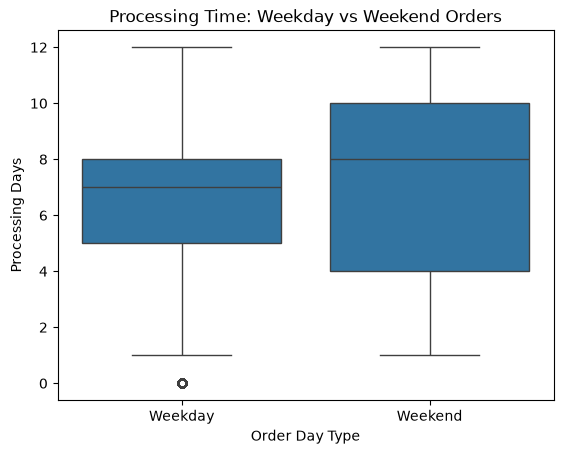

In [68]:
#Distribution of processing time between two groups
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=order_process_raw,
    x='day_type',
    y='processing_days'
)

plt.title('Processing Time: Weekday vs Weekend Orders')
plt.xlabel('Order Day Type')
plt.ylabel('Processing Days')
plt.show()

## Hypothesis 4 
**Weekend orders** take longer to process than weekday orders.  

-The hypothesis is supported. Weekend orders take longer to process than weekday orders. 

-Their average processing time is 6.9 days, compared with 5.9 days for weekdays, and their median is also higher (8 vs. 7 days).

**Proving Hypothesis 6**

In [69]:
merged_o_i = order_process_raw.merge(intern_data_study, on='order_id', how='outer')

In [70]:
merged_o_i['on_truck_pick_up_combined'] = merged_o_i['on_truck_scan_date'].fillna(merged_o_i['pickup_date'])
# in order to have more data for analysis, I created a on_truck_pick_up_combined that takes value from on truck scan date 
# or from pick up date if not available

In [71]:
merged_o_i['order_day_of_week'] = merged_o_i['order_date'].dt.day_name()
merged_o_i['ready_to_ship_day_of_week'] = merged_o_i['ready_to_ship_date'].dt.day_name()
merged_o_i['on_truck_pick_up_day_of_week'] = merged_o_i['on_truck_pick_up_combined'].dt.day_name()
merged_o_i.head(10)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days,day_type,ready_to_ship_date,pickup_date,storagetime,month_year,on_truck_pick_up_combined,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,NaT,NaT,2019-11-27,Wednesday,NaN,Wednesday
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,NaT,NaT,2019-11-27,Wednesday,NaN,Wednesday
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,NaT,NaT,2019-11-27,Wednesday,NaN,Wednesday
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,10,False,Weekend,NaT,NaT,NaT,NaT,2019-12-04,Sunday,NaN,Wednesday
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,5,False,Weekday,NaT,NaT,NaT,NaT,2019-12-18,Friday,NaN,Wednesday
5,2822,CA-2019-100202,2019-12-31,2020-01-08,Standard Processing,8,False,Weekday,NaT,NaT,NaT,NaT,2020-01-08,Tuesday,NaN,Wednesday
6,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,1 days,2019-09,2019-09-25,Friday,Tuesday,Wednesday
7,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,1 days,2019-09,2019-09-25,Friday,Tuesday,Wednesday
8,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,1 days,2019-09,2019-09-25,Friday,Tuesday,Wednesday
9,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,1 days,2019-09,2019-09-25,Friday,Tuesday,Wednesday


In [72]:
merged_o_i_enr = merged_o_i.copy()
# creating a copy for the analysis

In [73]:
def check_match(order_day, ready_day, truck_day):
    days = [
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"
    ]

    # Expected ready-to-ship day: the day after the order
    order_index = days.index(order_day)
    expected_ready = days[(order_index + 1) % 7]

    # Trucks leave on Monday, Wednesday, and Friday
    truck_days = ["Monday", "Wednesday", "Friday"]

    # Find the next available truck day
    ready_index = days.index(expected_ready)

    for i in range(7):
        possible_day = days[(ready_index + i) % 7]

        if possible_day in truck_days:
            expected_truck = possible_day
            break

    # Compare expected days with actual days
    ready_result = ready_day == expected_ready
    truck_result = truck_day == expected_truck
    overall_result = ready_result and truck_result

    return expected_ready, expected_truck, ready_result, truck_result, overall_result


# Create empty lists
expected_ready_list = []
expected_truck_list = []
ready_matches_list = []
truck_matches_list = []
overall_matches_list = []


# Check every order
for i in range(len(merged_o_i_enr)):

    order_day = merged_o_i_enr["order_day_of_week"].iloc[i]
    ready_day = merged_o_i_enr["ready_to_ship_day_of_week"].iloc[i]
    truck_day = merged_o_i_enr["on_truck_pick_up_day_of_week"].iloc[i]

    expected_ready, expected_truck, ready_result, truck_result, overall_result = check_match(
        order_day, ready_day, truck_day
    )

    expected_ready_list.append(expected_ready)
    expected_truck_list.append(expected_truck)
    ready_matches_list.append(ready_result)
    truck_matches_list.append(truck_result)
    overall_matches_list.append(overall_result)


# Add the results as new columns
merged_o_i_enr["ready_to_ship_day_of_week_expected"] = expected_ready_list
merged_o_i_enr["on_truck_pick_up_day_of_week_expected"] = expected_truck_list
merged_o_i_enr["ready_matches"] = ready_matches_list
merged_o_i_enr["truck_matches"] = truck_matches_list
merged_o_i_enr["matches_expected"] = overall_matches_list

In [74]:
merged_o_i_enr.head(10)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days,day_type,ready_to_ship_date,pickup_date,...,month_year,on_truck_pick_up_combined,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week,ready_to_ship_day_of_week_expected,on_truck_pick_up_day_of_week_expected,ready_matches,truck_matches,matches_expected
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaT,2019-11-27,Wednesday,NaN,Wednesday,Thursday,Friday,False,False,False
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaT,2019-11-27,Wednesday,NaN,Wednesday,Thursday,Friday,False,False,False
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaT,2019-11-27,Wednesday,NaN,Wednesday,Thursday,Friday,False,False,False
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,10,False,Weekend,NaT,NaT,...,NaT,2019-12-04,Sunday,NaN,Wednesday,Monday,Monday,False,False,False
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,5,False,Weekday,NaT,NaT,...,NaT,2019-12-18,Friday,NaN,Wednesday,Saturday,Monday,False,False,False
5,2822,CA-2019-100202,2019-12-31,2020-01-08,Standard Processing,8,False,Weekday,NaT,NaT,...,NaT,2020-01-08,Tuesday,NaN,Wednesday,Wednesday,Wednesday,False,True,False
6,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,...,2019-09,2019-09-25,Friday,Tuesday,Wednesday,Saturday,Monday,False,False,False
7,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,...,2019-09,2019-09-25,Friday,Tuesday,Wednesday,Saturday,Monday,False,False,False
8,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,...,2019-09,2019-09-25,Friday,Tuesday,Wednesday,Saturday,Monday,False,False,False
9,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,5,False,Weekday,2019-09-24,2019-09-25,...,2019-09,2019-09-25,Friday,Tuesday,Wednesday,Saturday,Monday,False,False,False


In [75]:
problem_list = []

for i in range(len(merged_o_i_enr)):
    ready_result = merged_o_i_enr["ready_matches"].iloc[i]
    truck_result = merged_o_i_enr["truck_matches"].iloc[i]

    if ready_result is None or truck_result is None:
        problem = None  # missing data, can't evaluate
    elif ready_result == True and truck_result == True:
        problem = "no problem — both matched"
    elif ready_result == False and truck_result == True:
        problem = "ready-to-ship was the problem"
    elif ready_result == True and truck_result == False:
        problem = "truck pickup was the problem"
    elif ready_result == False and truck_result == False:
        problem = "both were the problem"

    problem_list.append(problem)

merged_o_i_enr["problem_source"] = problem_list
#for every order, it looks at whether the Ready-to-Ship step matched, 
# whether the Truck pickup step matched, and labels each row with which step (if any) went wrong.


In [76]:
counts = merged_o_i_enr["problem_source"].value_counts()
percentages = merged_o_i_enr["problem_source"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": counts,
    "percent": percentages.round(1)
})
summary

,count,percent
problem_source,,
both were the problem,3984,63.9
ready-to-ship was the problem,2227,35.7
truck pickup was the problem,18,0.3
no problem — both matched,5,0.1


In [77]:
def expected_days_for_order(order_day):
    if order_day == "Monday":
        return 4
    elif order_day == "Tuesday":
        return 3
    elif order_day == "Wednesday":
        return 5
    elif order_day == "Thursday":
        return 6
    elif order_day == "Friday":
        return 5
    elif order_day == "Saturday":
        return 4
    elif order_day == "Sunday":
        return 4
    else:
        return None
    # prepare analysis to check if too fast or too slow

In [78]:
speed_list = []

for i in range(len(merged_o_i_enr)):
    order_day = merged_o_i_enr["order_day_of_week"].iloc[i]
    actual_days = merged_o_i_enr["processing_days"].iloc[i]

    expected_days = expected_days_for_order(order_day)

    if pd.isna(actual_days) or expected_days is None:
        speed = None
    elif actual_days < expected_days:
        speed = "faster than expected"
    elif actual_days > expected_days:
        speed = "slower than expected"
    else:
        speed = "on time"

    speed_list.append(speed)

merged_o_i_enr["expected_processing_days"] = merged_o_i_enr["order_day_of_week"].apply(expected_days_for_order)
merged_o_i_enr["speed_vs_expected"] = speed_list

In [79]:
merged_o_i_enr.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days,day_type,ready_to_ship_date,pickup_date,...,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week,ready_to_ship_day_of_week_expected,on_truck_pick_up_day_of_week_expected,ready_matches,truck_matches,matches_expected,problem_source,expected_processing_days,speed_vs_expected
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaN,Wednesday,Thursday,Friday,False,False,False,both were the problem,5,slower than expected
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaN,Wednesday,Thursday,Friday,False,False,False,both were the problem,5,slower than expected
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,Weekday,NaT,NaT,...,NaN,Wednesday,Thursday,Friday,False,False,False,both were the problem,5,slower than expected
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,10,False,Weekend,NaT,NaT,...,NaN,Wednesday,Monday,Monday,False,False,False,both were the problem,4,slower than expected
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,5,False,Weekday,NaT,NaT,...,NaN,Wednesday,Saturday,Monday,False,False,False,both were the problem,5,on time


In [80]:
merged_o_i_enr["speed_vs_expected"].value_counts()

speed_vs_expected
slower than expected    3626
on time                 1626
faster than expected     982
Name: count, dtype: int64

In [81]:
merged_o_i_enr["speed_vs_expected"].value_counts(normalize=True) * 100

speed_vs_expected
slower than expected    58.164902
on time                 26.082772
faster than expected    15.752326
Name: proportion, dtype: float64

In [82]:
merged_o_i_enr["ship_mode"].value_counts()

ship_mode
Standard Processing    4882
Express                1352
Name: count, dtype: int64

In [83]:
standard_only = merged_o_i_enr[merged_o_i_enr["ship_mode"] == "Standard Processing"].copy()
# narrowing it down to standard processing

In [84]:
ready_known = standard_only["ready_matches"].dropna().tolist()
truck_known = standard_only["truck_matches"].dropna().tolist()
overall_known = standard_only["matches_expected"].dropna().tolist()

print("Ready-to-Ship matches expected:", round(sum(ready_known) / len(ready_known) * 100, 1), "%  (n =", len(ready_known), ")")
print("Truck pickup matches expected:", round(sum(truck_known) / len(truck_known) * 100, 1), "%  (n =", len(truck_known), ")")
print("Both match expected:", round(sum(overall_known) / len(overall_known) * 100, 1), "%  (n =", len(overall_known), ")")


Ready-to-Ship matches expected: 0.1 %  (n = 4882 )
Truck pickup matches expected: 34.0 %  (n = 4882 )
Both match expected: 0.0 %  (n = 4882 )


In [85]:
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    subset = standard_only[standard_only["order_day_of_week"] == day]
    truck_results_for_day = subset["truck_matches"].dropna().tolist()

    if len(truck_results_for_day) > 0:
        pct = sum(truck_results_for_day) / len(truck_results_for_day) * 100
        print(day, ":", round(pct, 1), "% matched  (n =", len(truck_results_for_day), ")")
    else:
        print(day, ": no data")

Monday : 45.7 % matched  (n = 820 )
Tuesday : 81.7 % matched  (n = 848 )
Wednesday : 9.7 % matched  (n = 872 )
Thursday : 24.1 % matched  (n = 863 )
Friday : 8.4 % matched  (n = 742 )
Saturday : 39.4 % matched  (n = 254 )
Sunday : 28.0 % matched  (n = 483 )


In [86]:
counts = standard_only["speed_vs_expected"].value_counts()
percentages = standard_only["speed_vs_expected"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "percent": percentages.round(1)})
summary

,count,percent
speed_vs_expected,,
slower than expected,3544,72.6
on time,1327,27.2
faster than expected,11,0.2


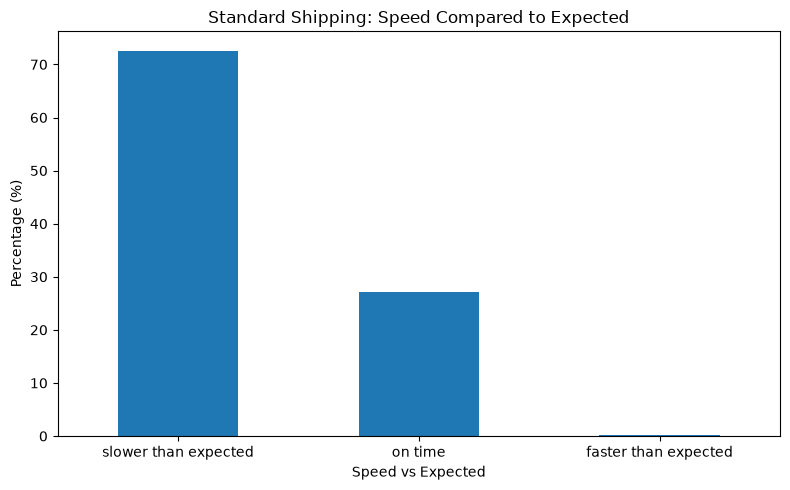

In [87]:
import matplotlib.pyplot as plt

counts = standard_only["speed_vs_expected"].value_counts()
percentages = standard_only["speed_vs_expected"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": counts,
    "percent": percentages.round(1)
})

summary["percent"].plot(kind="bar", figsize=(8, 5))

plt.title("Standard Shipping: Speed Compared to Expected")
plt.xlabel("Speed vs Expected")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [88]:
# among all checkable Standard orders
counts = standard_only["problem_source"].value_counts()
percentages = standard_only["problem_source"].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": counts, "percent": percentages.round(1)})
summary

,count,percent
problem_source,,
both were the problem,3221,66.0
ready-to-ship was the problem,1658,34.0
truck pickup was the problem,3,0.1


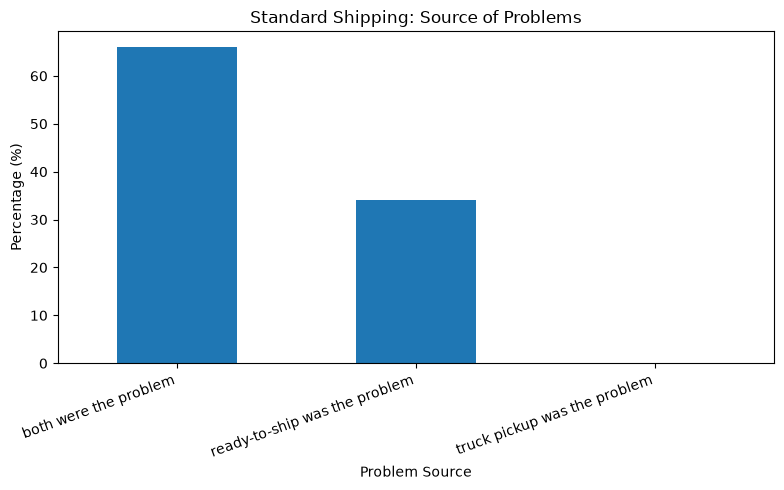

In [89]:
import matplotlib.pyplot as plt

summary["percent"].plot(kind="bar", figsize=(8, 5))

plt.title("Standard Shipping: Source of Problems")
plt.xlabel("Problem Source")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Hypothesis 6
**Some orders** miss the next available truck. 

- The hypothesis “Some orders miss the next available truck” is supported for Standard Shipping.

- The results show that 72.6% of Standard orders were slower than expected, while only 27.2% were on time.
However, the main issue was not the truck pickup alone. 

- In 66.0% of cases, both the ready-to-ship timing and truck timing were identified as problems, while only 0.1% were caused specifically by truck pickup.

- Therefore, Standard Shipping orders do sometimes miss the expected truck, but delays are mainly related to both warehouse readiness and truck scheduling.



**Proving Hypothesis 7**

In [90]:
#Merge the campaign and order data using order_id to create a dataset for analyzing transportation time
#Then, check the first 10 rows and the dataset size.
transport_time = campaign_raw.merge(order_process_raw, on='order_id', how='left')
transport_time.head(10)
transport_time.shape

transport_time.head(10)

,order_id,arrival_scan_date,customer_name,row_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days,day_type
0,CA-2019-109666,2019-05-03,Kunst Miller,7108,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
1,CA-2019-109666,2019-05-03,Kunst Miller,7109,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
2,CA-2019-109666,2019-05-03,Kunst Miller,7110,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
3,CA-2019-109666,2019-05-03,Kunst Miller,7111,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
4,CA-2019-109666,2019-05-03,Kunst Miller,7112,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
5,CA-2019-109666,2019-05-03,Kunst Miller,7113,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
6,CA-2019-109666,2019-05-03,Kunst Miller,7114,2019-04-19,2019-04-29,Standard Processing,10,False,Weekday
7,CA-2019-138933,2019-05-03,Jack Lebron,3235,2019-04-24,2019-04-29,Express,5,False,Weekday
8,CA-2019-130001,2019-05-03,Heather Kirkland,359,2019-04-23,2019-05-01,Standard Processing,8,False,Weekday
9,CA-2019-113061,2019-05-06,Ed Ludwig,1037,2019-04-22,2019-04-29,Standard Processing,7,False,Weekday


In [110]:
#Calculate the transportation time by subtracting the truck scan date from the arrival scan date, then calculate the average transportation time.
transport_time['transportation_time_right'] = transport_time['arrival_scan_date'] - transport_time['on_truck_scan_date']
transport_time['transportation_time_right'].mean()

Timedelta('4 days 13:28:22.994011')

In [113]:
#Calculate the average transportation time for each shipping mode to compare their delivery performance
mean_transportation_time = transport_time.groupby('ship_mode')['transportation_time_right'].mean()
mean_transportation_time.to_frame()

,transportation_time_right
ship_mode,
Express,4 days 14:06:29.189189
Standard Processing,4 days 13:17:32.307692


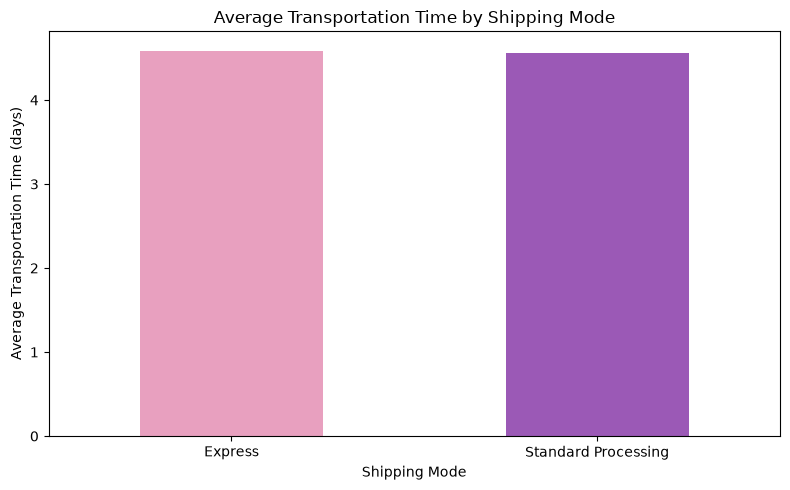

In [93]:
import matplotlib.pyplot as plt

mean_transportation_time = transport_time.groupby('ship_mode')['transportation_time_right'].mean()

# Convert timedelta to days
mean_days = mean_transportation_time.dt.total_seconds() / (24 * 60 * 60)

colors = ["#E8A0BF", "#9B59B6"]

mean_days.plot(
    kind="bar",
    figsize=(8, 5),
    color=colors
)

plt.title("Average Transportation Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Transportation Time (days)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Hypothesis 7

**Transportation** takes approximately three days after shipment.
The hypothesis “Transportation takes approximately three days after shipment” is not supported by the results. The average transportation time is approximately 4.6 days for both Express and Standard Processing, which is longer than the expected 3 days.  

Express: ~4 days 14 hours
Standard Processing: ~4 days 13 hours. 

Therefore, transportation takes approximately 4–5 days rather than 3 days.

**Proving Hypothesis 8**

In [94]:
#merging
order_analysis = order_process_raw.merge(intern_data_study,on='order_id', how='inner')

In [95]:
#to check the date are actually date
date_columns = ['order_date', 'ready_to_ship_date', 'pickup_date',  'on_truck_scan_date']

for col in date_columns: order_analysis[col] = pd.to_datetime(order_analysis[col], errors='coerce')

In [96]:
#To calculate warehouse processing time, Order placed → Ready to Ship
order_analysis['warehouse_processing_days'] = (order_analysis['ready_to_ship_date']- order_analysis['order_date']).dt.days

In [97]:
#To calculate waiting-for-pickup time, Ready to Ship → Pickup
#This si the day waited for pickup

order_analysis['waiting_for_pickup_days'] = (order_analysis['pickup_date']- order_analysis['ready_to_ship_date']).dt.days

In [98]:
#To compare the variation, to knwo whether the most variation in delivery time comes from warehouse processing or waiting for a truck.
order_analysis[['warehouse_processing_days', 'waiting_for_pickup_days']].std()

warehouse_processing_days    1.786763
waiting_for_pickup_days      0.952005
dtype: float64

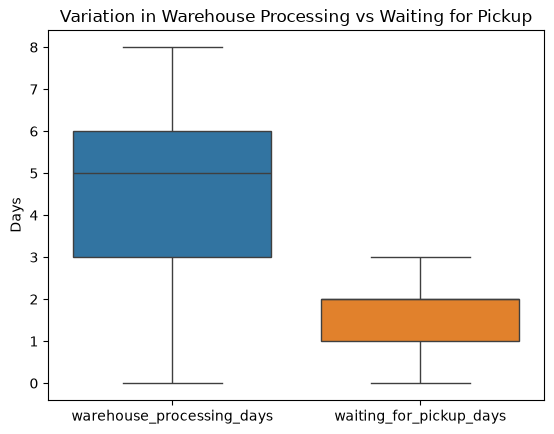

In [99]:
#On average, orders spend much more time being processed by the warehouse than waiting for pickup.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=order_analysis[['warehouse_processing_days', 'waiting_for_pickup_days']])

plt.title('Variation in Warehouse Processing vs Waiting for Pickup')
plt.ylabel('Days')
plt.show()

## Hypothesis 8 
 **Most variation in delivery time** comes from warehouse processing or waiting for a truck.  

 -The hypothesis is supported. Warehouse processing has a higher average variation (1.79 days) than waiting for pickup (0.95 days).   

 -This suggests that warehouse processing contributes more to delivery-time variation than waiting for a truck in Standard Shipping.

**Proving Hypothesis 5 + 9**

In [100]:
# Calculate the waiting time between being ready for shipping and pickup
intern_data_study['waiting_days'] = ( intern_data_study['pickup_date'] - intern_data_study['ready_to_ship_date']).dt.days

In [101]:
# Identify the weekday on which the order was ready for shipping
intern_data_study['ready_weekday'] = (intern_data_study['ready_to_ship_date'].dt.day_name())

In [102]:
# Compare waiting time by weekday
intern_data_study.groupby('ready_weekday')['waiting_days'].describe()
#This tells us that Friday orders have the longest waiting time.

,count,mean,std,min,25%,50%,75%,max
ready_weekday,,,,,,,,
Friday,47.0,2.297872,1.283929,0.0,3.0,3.0,3.0,3.0
Monday,129.0,1.790698,0.898562,0.0,2.0,2.0,2.0,3.0
Thursday,36.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Tuesday,43.0,1.186047,0.393750,1.0,1.0,1.0,1.0,2.0
Wednesday,35.0,1.514286,0.817868,0.0,1.0,2.0,2.0,2.0


In [103]:
# Add ship mode information to the intern data
ship_mode_data = order_process_raw[ ['order_id', 'ship_mode']].drop_duplicates()

intern_data_study = intern_data_study.merge(ship_mode_data, on='order_id', how='left')

In [104]:
# Check the available shipping modes
display(intern_data_study['ship_mode'].value_counts())

ship_mode
Standard Processing    225
Express                 65
Name: count, dtype: int64

In [105]:
# Compare waiting time between shipping modes
intern_data_study.groupby('ship_mode')['waiting_days'].describe()

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
Express,65.0,0.400000,0.524404,0.0,0.0,0.0,1.0,2.0
Standard Processing,225.0,2.013333,0.691014,1.0,2.0,2.0,2.0,3.0


In [106]:
# Analyze waiting time for Standard orders by weekday
standard_orders = intern_data_study[ intern_data_study['ship_mode'] == 'Standard Processing']

standard_orders.groupby('ready_weekday')['waiting_days'].describe()

#Standard:Order ready → waits for the available truck.
#Express:Order ready → leaves the same day.
#to know whether more frequent pickups would reduce waiting time, Standard orders give us the clearest evidence.

,count,mean,std,min,25%,50%,75%,max
ready_weekday,,,,,,,,
Friday,36.0,3.000000,0.000000,3.0,3.0,3.0,3.0,3.0
Monday,105.0,2.180952,0.386825,2.0,2.0,2.0,2.0,3.0
Thursday,21.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Tuesday,38.0,1.184211,0.392859,1.0,1.0,1.0,1.0,2.0
Wednesday,25.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0


In [107]:
# Estimate the potential waiting-time reduction with daily pickups
standard_orders['potential_saving'] = (standard_orders['waiting_days'])
#Potential Saving = Current Waiting Time − New Waiting Time -> Potential Saving = waiting_days - 0

In [108]:
# Average potential saving by weekday
standard_orders.groupby('ready_weekday')['potential_saving'].mean()

ready_weekday
Friday       3.000000
Monday       2.180952
Thursday     1.000000
Tuesday      1.184211
Wednesday    2.000000
Name: potential_saving, dtype: float64

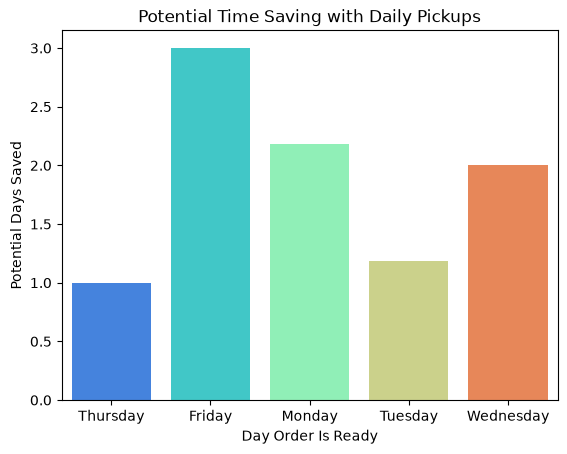

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the potential time saving from daily pickups
sns.barplot(
    data=standard_orders,
    x='ready_weekday',
    y='potential_saving',
    errorbar=None,
    palette='rainbow',
    hue='ready_weekday',
    legend=False
)

plt.title('Potential Time Saving with Daily Pickups')
plt.xlabel('Day Order Is Ready')
plt.ylabel('Potential Days Saved')

plt.show()

## Hypothesis 5 + 9
**Orders ready on Friday** experience longer waiting times because trucks leave only on Monday, Wednesday, and Friday.  

-The hypothesis is supported by the results, as orders ready on Friday have the highest average potential saving of 3 days, indicating longer waiting times.

**Daily pickups** would reduce total delivery time.  

 -The potential time saving is highest for Friday orders (3.0 days), followed by Monday orders (2.18 days) and Wednesday orders (2.0 days). Thursday orders have the lowest potential saving at 1.0 day, while Tuesday orders could save around 1.18 days.  

-This suggests that daily pickups could reduce waiting time and potentially shorten total delivery time, especially for orders that are ready on Fridays --> not the actual reduction in total delivery time.